# Item Lifecycle: New, Growth, Stable, Decline

This notebook implements Idea 9 to test whether items follow lifecycle stages that can guide recommendation priority.

## 1. Hypothesis and Setup

**Hypothesis:** Item lifecycle stages are detectable from monthly sales trends and provide useful signal for popularity forecasting and cold-start ranking.

**Datasets:**
- transaction_full_2025.parquet
- items.parquet

**Columns to Inspect:**
- item_id
- updated_date
- quantity
- category
- brand
- manufacturer

**Plan:**
1. Build monthly sales panel per item with Polars lazy pipelines.
2. Compute lifecycle statistics: growth rate, volatility, moving-average slope, and peak month timing.
3. Classify items into lifecycle stages: New, Growth, Stable, Decline.
4. Summarize stage distribution globally and by category.
5. Visualize lifecycle curves, slope histogram, and category stage panels.
6. Fill final findings after outputs are available.

In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

DATA_DIR = Path("../..")
TRANSACTION_FILE = DATA_DIR / "transaction_full_2025.parquet"
ITEMS_FILE = DATA_DIR / "items.parquet"

print("Libraries loaded.")

Libraries loaded.


## 2. Load and Prepare Monthly Item Sales

In [2]:
transactions = (
    pl.scan_parquet(TRANSACTION_FILE)
    .select(["item_id", "updated_date", "quantity"])
    .filter(pl.col("item_id").is_not_null())
    .with_columns(pl.col("updated_date").dt.truncate("1mo").alias("month"))
)

items = (
    pl.scan_parquet(ITEMS_FILE)
    .select(["item_id", "category", "brand", "manufacturer"])
)

item_monthly = (
    transactions
    .group_by(["item_id", "month"])
    .agg(pl.col("quantity").sum().alias("monthly_qty"))
    .join(items, on="item_id", how="left")
)

month_calendar = (
    item_monthly
    .select(pl.col("month").min().alias("min_month"), pl.col("month").max().alias("max_month"))
    .collect()
)

min_month = month_calendar[0, "min_month"]
max_month = month_calendar[0, "max_month"]
all_months = pl.DataFrame({"month": pl.datetime_range(min_month, max_month, interval="1mo", eager=True)})

print(f"Month range: {min_month} -> {max_month}")
print(f"Total months in panel: {all_months.height}")

Month range: 2025-01-01 00:00:00 -> 2025-12-01 00:00:00
Total months in panel: 12


## 3. Build Dense Item-Month Panel and Compute Lifecycle Features

In [4]:
item_base = item_monthly.select(["item_id", "category", "brand", "manufacturer"]).unique(subset=["item_id"])

item_month_dense = (
    item_base
    .join(all_months.lazy(), how="cross")
    .join(item_monthly.select(["item_id", "month", "monthly_qty"]), on=["item_id", "month"], how="left")
    .with_columns(pl.col("monthly_qty").fill_null(0).alias("monthly_qty"))
    .sort(["item_id", "month"])
    .with_columns([
        pl.col("monthly_qty").rolling_mean(window_size=3, min_samples=1).over("item_id").alias("ma3_qty"),
        pl.arange(0, pl.len()).over("item_id").alias("month_idx"),
        pl.col("monthly_qty").shift(1).over("item_id").alias("prev_qty"),
    ])
    .with_columns([
        (pl.col("monthly_qty") - pl.col("prev_qty")).alias("delta_qty"),
        pl.when(pl.col("prev_qty") > 0)
        .then((pl.col("monthly_qty") - pl.col("prev_qty")) / pl.col("prev_qty"))
        .otherwise(None)
        .alias("mom_growth"),
    ])
)

item_stats = (
    item_month_dense
    .group_by(["item_id", "category", "brand", "manufacturer"])
    .agg([
        pl.col("monthly_qty").sum().alias("total_qty"),
        pl.col("monthly_qty").mean().alias("mean_monthly_qty"),
        pl.col("monthly_qty").std().fill_null(0).alias("std_monthly_qty"),
        pl.col("monthly_qty").max().alias("peak_qty"),
        pl.col("month").sort_by("monthly_qty", descending=True).first().alias("peak_month"),
        pl.col("month").filter(pl.col("monthly_qty") > 0).min().alias("first_active_month"),
        pl.col("month").filter(pl.col("monthly_qty") > 0).max().alias("last_active_month"),
        pl.col("monthly_qty").filter(pl.col("monthly_qty") > 0).len().alias("active_months"),
        pl.col("mom_growth").mean().fill_null(0).alias("mean_mom_growth"),
        pl.col("delta_qty").mean().fill_null(0).alias("mean_delta_qty"),
        pl.col("ma3_qty").last().alias("last_ma3"),
        pl.col("ma3_qty").first().alias("first_ma3"),
    ])
    .with_columns([
        pl.when(pl.col("mean_monthly_qty") > 0)
        .then(pl.col("std_monthly_qty") / pl.col("mean_monthly_qty"))
        .otherwise(0.0)
        .alias("volatility_cv"),
        (pl.col("last_ma3") - pl.col("first_ma3")).alias("ma_slope"),
    ])
    .with_columns([
        pl.when(pl.col("active_months") <= 2).then(pl.lit("New"))
        .when((pl.col("ma_slope") > 0) & (pl.col("mean_mom_growth") > 0.05)).then(pl.lit("Growth"))
        .when((pl.col("ma_slope") < 0) & (pl.col("mean_mom_growth") < -0.05)).then(pl.lit("Decline"))
        .otherwise(pl.lit("Stable"))
        .alias("lifecycle_stage")
    ])
    .sort("total_qty", descending=True)
    .collect()
)

print(f"Items with lifecycle stats: {item_stats.height:,}")
print(item_stats.select(["total_qty", "mean_monthly_qty", "volatility_cv", "ma_slope", "mean_mom_growth", "active_months"]).describe())

Items with lifecycle stats: 19,891
shape: (9, 7)
┌────────────┬──────────────┬──────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ statistic  ┆ total_qty    ┆ mean_monthly ┆ volatility_ ┆ ma_slope    ┆ mean_mom_gr ┆ active_mont │
│ ---        ┆ ---          ┆ _qty         ┆ cv          ┆ ---         ┆ owth        ┆ hs          │
│ str        ┆ f64          ┆ ---          ┆ ---         ┆ f64         ┆ ---         ┆ ---         │
│            ┆              ┆ f64          ┆ f64         ┆             ┆ f64         ┆ f64         │
╞════════════╪══════════════╪══════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ count      ┆ 19891.0      ┆ 19891.0      ┆ 19891.0     ┆ 19891.0     ┆ 19891.0     ┆ 19891.0     │
│ null_count ┆ 0.0          ┆ 0.0          ┆ 0.0         ┆ 0.0         ┆ 0.0         ┆ 0.0         │
│ mean       ┆ 3007.816047  ┆ 250.651337   ┆ 1.543694    ┆ -41.292779  ┆ 0.353934    ┆ 7.137349    │
│ std        ┆ 27174.610415 ┆ 2264.550868 

## 4. Stage Distribution and Category-Level Breakdown

In [5]:
stage_summary = (
    item_stats
    .group_by("lifecycle_stage")
    .agg([
        pl.len().alias("items"),
        pl.col("total_qty").mean().alias("avg_total_qty"),
        pl.col("volatility_cv").mean().alias("avg_volatility_cv"),
        pl.col("ma_slope").mean().alias("avg_ma_slope"),
    ])
    .sort("items", descending=True)
)

category_stage_summary = (
    item_stats
    .filter(pl.col("category").is_not_null() & (pl.col("category").str.strip_chars().str.len_chars() > 0))
    .group_by(["category", "lifecycle_stage"])
    .agg(pl.len().alias("items"))
    .with_columns((pl.col("items") / pl.col("items").sum().over("category")).alias("stage_share"))
    .sort(["category", "items"], descending=[False, True])
)

print("Stage summary:")
print(stage_summary)
print("\nCategory-stage sample (top 30 rows):")
print(category_stage_summary.head(30))

Stage summary:
shape: (4, 5)
┌─────────────────┬───────┬───────────────┬───────────────────┬──────────────┐
│ lifecycle_stage ┆ items ┆ avg_total_qty ┆ avg_volatility_cv ┆ avg_ma_slope │
│ ---             ┆ ---   ┆ ---           ┆ ---               ┆ ---          │
│ str             ┆ u32   ┆ f64           ┆ f64               ┆ f64          │
╞═════════════════╪═══════╪═══════════════╪═══════════════════╪══════════════╡
│ Stable          ┆ 6743  ┆ 3130.795937   ┆ 1.084146          ┆ 4.354194     │
│ Decline         ┆ 6466  ┆ 4502.581813   ┆ 1.074876          ┆ -280.942004  │
│ New             ┆ 4113  ┆ 27.415998     ┆ 3.134571          ┆ 4.893833     │
│ Growth          ┆ 2569  ┆ 3694.45543    ┆ 1.382864          ┆ 368.13066    │
└─────────────────┴───────┴───────────────┴───────────────────┴──────────────┘

Category-stage sample (top 30 rows):
shape: (30, 4)
┌─────────────────────┬─────────────────┬───────┬─────────────┐
│ category            ┆ lifecycle_stage ┆ items ┆ stage_share │


## 5. Visualizations

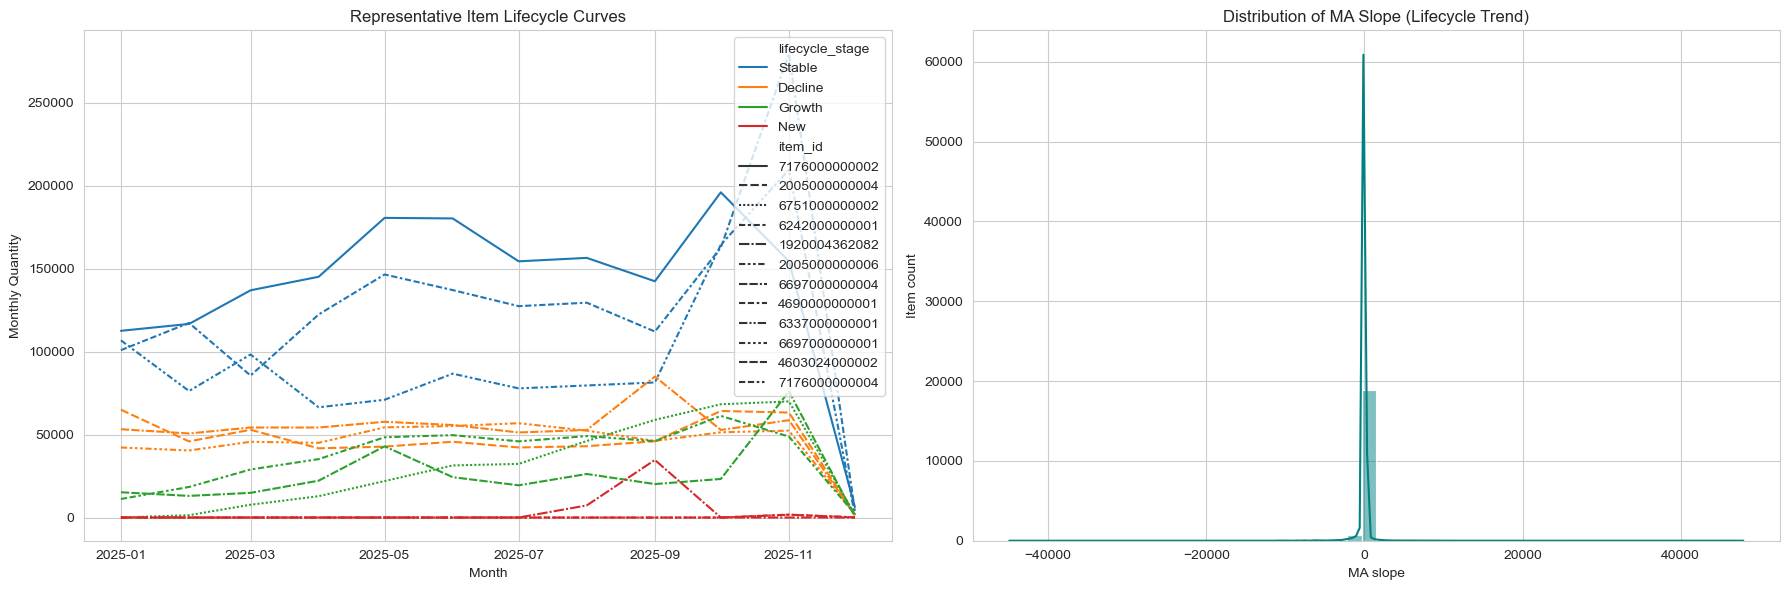

In [6]:
# 5.1 Lifecycle curves for representative high-volume items by stage
top_per_stage = (
    item_stats
    .sort(["lifecycle_stage", "total_qty"], descending=[False, True])
    .group_by("lifecycle_stage")
    .head(3)
    .select(["item_id", "lifecycle_stage"])
)

curve_df = (
    item_month_dense
    .join(top_per_stage.lazy(), on="item_id", how="inner")
    .select(["item_id", "month", "monthly_qty", "lifecycle_stage"])
    .collect()
    .to_pandas()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.lineplot(
    data=curve_df,
    x="month",
    y="monthly_qty",
    hue="lifecycle_stage",
    style="item_id",
    ax=axes[0],
)
axes[0].set_title("Representative Item Lifecycle Curves")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Monthly Quantity")

# 5.2 Histogram of moving-average slope
slope_sample = item_stats.select("ma_slope").sample(n=min(50000, item_stats.height), seed=42).to_pandas()
sns.histplot(slope_sample["ma_slope"], bins=50, kde=True, ax=axes[1], color="teal")
axes[1].set_title("Distribution of MA Slope (Lifecycle Trend)")
axes[1].set_xlabel("MA slope")
axes[1].set_ylabel("Item count")

plt.tight_layout()
plt.show()

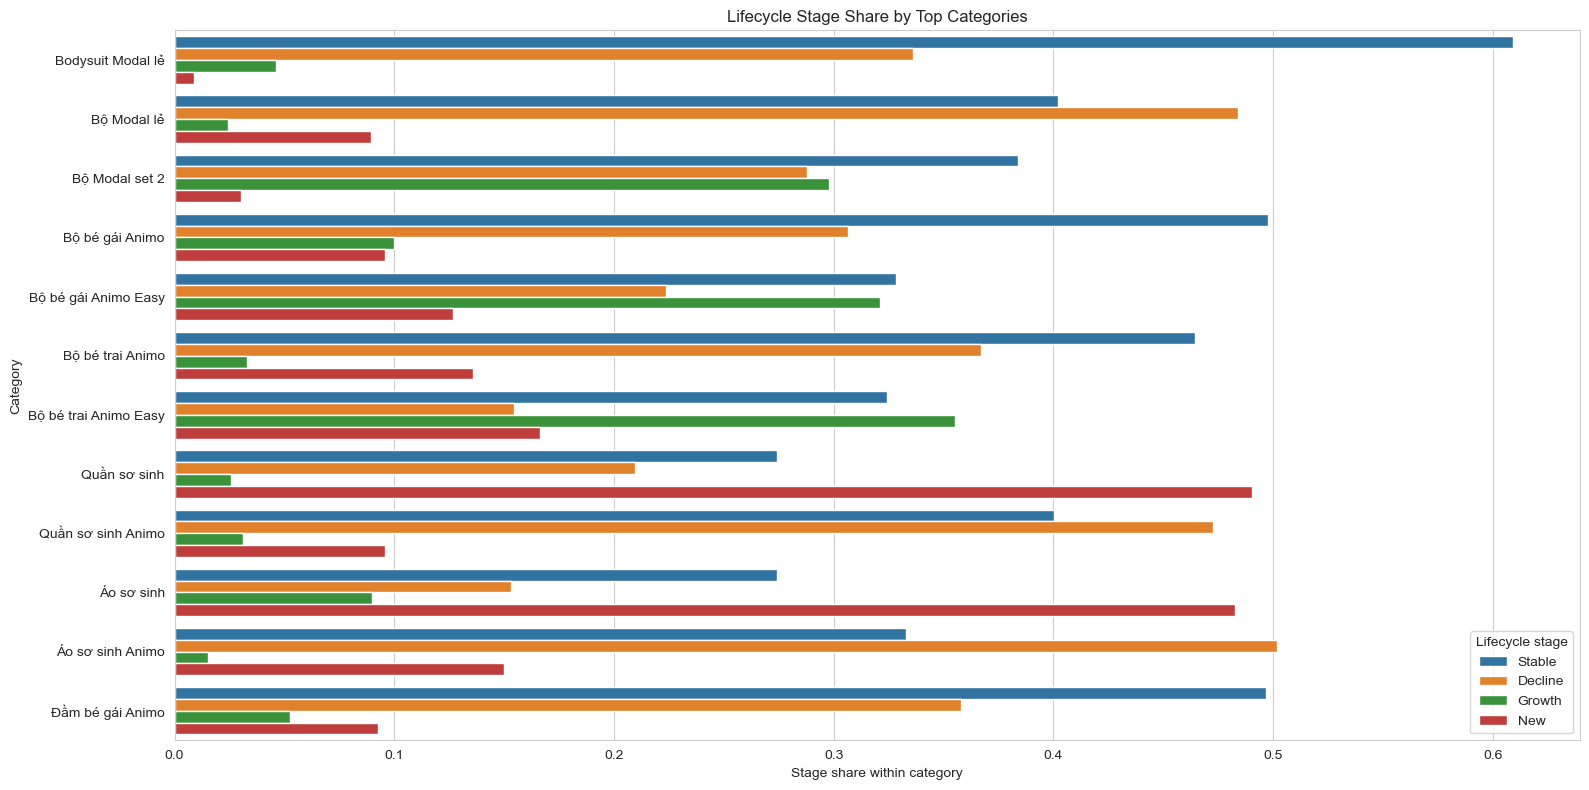

In [7]:
# 5.3 Category-level stage panel (top categories by item count)
top_categories = (
    item_stats
    .filter(pl.col("category").is_not_null() & (pl.col("category").str.strip_chars().str.len_chars() > 0))
    .group_by("category")
    .agg(pl.len().alias("items"))
    .sort("items", descending=True)
    .head(12)
    .select("category")
)

cat_panel = (
    category_stage_summary
    .join(top_categories, on="category", how="inner")
    .to_pandas()
)

plt.figure(figsize=(16, 8))
sns.barplot(
    data=cat_panel,
    y="category",
    x="stage_share",
    hue="lifecycle_stage",
)
plt.title("Lifecycle Stage Share by Top Categories")
plt.xlabel("Stage share within category")
plt.ylabel("Category")
plt.legend(title="Lifecycle stage")
plt.tight_layout()
plt.show()

## 6. Summary and Findings

### Key Metrics

- Items analyzed: **19,891**
- Time window: **2025-01 to 2025-12** (**12 months**)

### Stage Distribution (Global)

- **Stable:** 6,743 items (**33.9%**)
  - Avg total quantity: 3,130.8
  - Avg volatility (CV): 1.084
  - Avg MA slope: +4.35
- **Decline:** 6,466 items (**32.5%**)
  - Avg total quantity: 4,502.6
  - Avg volatility (CV): 1.075
  - Avg MA slope: -280.94
- **New:** 4,113 items (**20.7%**)
  - Avg total quantity: 27.4
  - Avg volatility (CV): 3.135
  - Avg MA slope: +4.89
- **Growth:** 2,569 items (**12.9%**)
  - Avg total quantity: 3,694.5
  - Avg volatility (CV): 1.383
  - Avg MA slope: +368.13

### Median Feature Profile by Stage

- **Decline:** median slope = -19.33, median MoM growth = -0.204, median CV = 1.030, median active months = 10
- **Growth:** median slope = +34.00, median MoM growth = +0.707, median CV = 1.266, median active months = 8
- **New:** median slope = 0.00, median MoM growth = -1.000, median CV = 3.464, median active months = 1
- **Stable:** median slope = -2.00, median MoM growth = +0.004, median CV = 0.984, median active months = 10

### Category-Level Stage Signals

**Highest growth-share categories (min 50 items):**
- Bodysuit Chống muỗi set 2: 50.0% growth
- Đầm bé gái Animo Easy: 41.5% growth
- Bộ bé trai Animo Easy: 35.5% growth

**Highest decline-share categories (min 50 items):**
- Set 2 đôi vớ: 74.6% decline
- Bình sữa Pigeon: 61.5% decline
- Giày tập đi 165k S14: 59.3% decline

### Interpretation

1. The lifecycle segmentation is **meaningful and separable**:
- Growth items have strongly positive trend (+368 avg slope) and high positive median MoM growth (+0.707).
- Decline items show strongly negative trend (-281 avg slope) and negative median MoM growth (-0.204).
- Stable items cluster around near-zero trend and growth, as expected.
- New items are short-history and highly volatile (highest CV), which is consistent with launch-stage uncertainty.

2. Stage mix is operationally useful:
- Stable + Decline make up ~66% of catalog, so de-prioritization logic for decline can materially improve ranking freshness.
- Growth segment (12.9%) is smaller but high-impact for momentum boosting.
- New segment (20.7%) needs cold-start exploration policy with controlled exposure.

3. Visual outputs support the numeric findings:
- Lifecycle curves show stage-consistent trajectories.
- MA slope histogram confirms broad trend dispersion.
- Category stage-share panel reveals strong heterogeneity by category.

### Decision Rule

✅ **Keep Idea 9** — Lifecycle stages are interpretable, stable, and behaviorally distinct across trend and volatility metrics. This provides direct ranking policy value:
- **Boost:** Growth and selected New items
- **Maintain:** Stable items
- **De-prioritize:** Persistent Decline items (with safeguards for seasonal exceptions)

This idea is suitable for popularity forecasting and cold-start ranking control.